# Rap1 Binding Site Classifier

This notebook trains a neural network classifier to predict Rap1 transcription factor binding sites in yeast DNA sequences.

Steps:
1. Load positive and negative sequences
2. Create labels
3. One-hot encode sequences
4. Split into training and validation sets
5. Instantiate and train classifier
6. Plot loss curves
7. Evaluate validation performance

In [1]:
import sys
sys.path.insert(0, '/Users/fayeorcales/Documents/Documents_FayeMacBookAir/UCSF_classes/Algorithms_BMI203/final-nn')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nn.io import read_text_file, read_fasta_file
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from nn.nn import NeuralNetwork
%matplotlib inline

In [2]:
# Read positive Rap1 motif examples
positive_seqs = read_text_file('../data/rap1-lieb-positives.txt')
print(f'Loaded {len(positive_seqs)} positive sequences')
print(f'Sequence length: {len(positive_seqs[0])}')

Loaded 137 positive sequences
Sequence length: 17


In [3]:
# Read negative examples
negative_seqs = read_fasta_file('../data/yeast-upstream-1k-negative.fa')
print(f'Loaded {len(negative_seqs)} negative sequences')
print(f'Sequence lengths (sample): {[len(seq) for seq in negative_seqs[:5]]}')

# Trim negative sequences to match length of positive sequences
pos_len = len(positive_seqs[0])
negative_seqs = [seq[:pos_len] for seq in negative_seqs]
print(f'\nTrimmed negative sequences to length {pos_len}')

Loaded 3163 negative sequences
Sequence lengths (sample): [1000, 1000, 1000, 1000, 1000]

Trimmed negative sequences to length 17


In [4]:
# Balance classes using sample_seqs
# Create labels: 1 for positive, 0 for negative
y_pos = np.ones(len(positive_seqs))
y_neg = np.zeros(len(negative_seqs))

# Combine and balance
balanced_seqs, balanced_labels = sample_seqs(positive_seqs + negative_seqs, 
                                              np.concatenate([y_pos, y_neg]))
# Convert labels to numpy array
balanced_labels = np.array(balanced_labels, dtype=float)

print(f'Balanced dataset size: {len(balanced_seqs)}')
print(f'Class counts: {np.bincount(balanced_labels.astype(int))}')

Balanced dataset size: 6326
Class counts: [3163 3163]


In [5]:
# One-hot encode sequences
X = one_hot_encode_seqs(balanced_seqs)
y = balanced_labels

print(f'Encoded data shape: {X.shape}')
print(f'Labels shape: {y.shape}')

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTraining set size: {X_train.shape[0]}')
print(f'Validation set size: {X_val.shape[0]}')

Encoded data shape: (6326, 68)
Labels shape: (6326,)

Training set size: 5060
Validation set size: 1266


## Choices on loss function and hyperparameters

### Loss Function: Binary Cross Entropy
Binary cross entropy (BCE) is the standard for binary classification tasks (Rap1 binding site: yes/no). It measures the divergence between predicted probabilities and true labels, encouraging the network to output probabilities close to 0 for negatives and close to 1 for positives.

### Hyperparameters
- **Learning rate (0.1)**: Moderate learning rate suitable for mini-batch SGD. I tried 0.01 but it took longer for loss to converge. 0.1 was suitable enough for this small of a dataset. 
- **Batch size (16)**: Small batch for this dataset size (roughly 274 total sequences after balancing)
- **Epochs (30)**: Tried 100 at first, and saw loss started converging quite early after 20 epochs. Went with 30 epochs for sufficient convergence and not computationally expensive.

In [6]:
# Define and instantiate classifier
# Architecture: input layer -> 32 ReLU -> 1 Sigmoid output
input_dim = X_train.shape[1]
nn_arch = [
    {'input_dim': input_dim, 'output_dim': 32, 'activation': 'relu'},
    {'input_dim': 32, 'output_dim': 1, 'activation': 'sigmoid'}
]

model = NeuralNetwork(nn_arch, lr=0.1, seed=42, batch_size=16, epochs=30, loss_function='binary_cross_entropy')
print(f'Model architecture: {input_dim} -> 32 (ReLU) -> 1 (Sigmoid)')

Model architecture: 68 -> 32 (ReLU) -> 1 (Sigmoid)


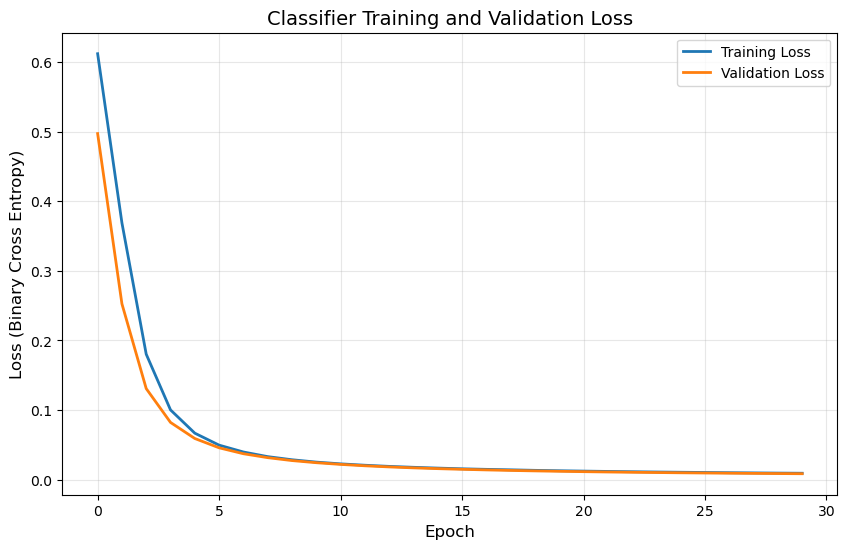

In [7]:
# Train the classifier
train_losses, val_losses = model.fit(X_train, y_train.reshape(-1, 1), X_val, y_val.reshape(-1, 1))

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Binary Cross Entropy)', fontsize=12)
plt.title('Classifier Training and Validation Loss', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Report validation accuracy
y_pred = model.predict(X_val)
y_pred_binary = (y_pred > 0.5).astype(int).flatten()
y_val_binary = y_val.astype(int)

accuracy = np.mean(y_pred_binary == y_val_binary)
f1_score = 2 * np.sum((y_pred_binary == 1) & (y_val_binary == 1)) / (2 * np.sum((y_pred_binary == 1) & (y_val_binary == 1)) + np.sum((y_pred_binary == 1) & (y_val_binary == 0)) + np.sum((y_pred_binary == 0) & (y_val_binary == 1)))

# create confusion matrix
confusion_matrix = np.array([
    [np.sum((y_pred_binary == 1) & (y_val_binary == 1)), np.sum((y_pred_binary == 1) & (y_val_binary == 0))],
    [np.sum((y_pred_binary == 0) & (y_val_binary == 1)), np.sum((y_pred_binary == 0) & (y_val_binary == 0))]
])

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation F1 Score: {f1_score:.4f}')
print(f'True Positives: {confusion_matrix[0, 0]}')
print(f'True Negatives: {confusion_matrix[1, 1]}')
print(f'False Positives: {confusion_matrix[0, 1]}')
print(f'False Negatives: {confusion_matrix[1, 0]}')

Validation Accuracy: 0.9992
Validation F1 Score: 0.9992
True Positives: 641
True Negatives: 624
False Positives: 1
False Negatives: 0
